# Boosting Algorithms: A Comprehensive Guide

## Introduction to Boosting

Boosting is a powerful ensemble learning technique that combines the predictions of several "base" or "weak" models to produce a more robust and accurate "strong" model. The core idea is to train models sequentially, with each new model trying to correct the errors of the previous ones.

**Boosting (e.g., AdaBoost, Gradient Boosting):** Trains models sequentially, with each new model trying to correct the errors of the previous ones.

### Why Use Boosting?

*   **Improved Accuracy:** Boosting algorithms are known for achieving very high accuracy.
*   **Handles Complex Relationships:** They can model complex non-linear relationships in data.
*   **Reduced Bias:** By focusing on errors, boosting effectively reduces the bias of the overall model.

### Weak Learners vs. Strong Learners

*   **Weak Learner (Base Learner):** A model that performs slightly better than random guessing (e.g., shallow decision trees).
*   **Strong Learner:** The final, highly accurate model created by combining many weak learners in a boosting framework.

### The Core Idea of Boosting

Boosting algorithms work iteratively and sequentially:

1.  **Initial Model:** Train a weak learner on the original dataset.
2.  **Focus on Mistakes:** Identify the data points that the current weak learner misclassified or predicted poorly.
3.  **Increase Weight/Attention:** Give more "weight" or "attention" to these misclassified/poorly predicted data points in the next iteration.
4.  **Train New Learner:** Train a new weak learner, specifically trying to correctly predict the now "more important" (weighted) misclassified examples.
5.  **Combine & Repeat:** Add this new weak learner to the ensemble. Repeat the process, with each new learner trying to fix the remaining errors.
6.  **Weighted Voting:** The final prediction is made by combining the predictions of all weak learners, often giving more weight to the learners that performed better.

## Key Boosting Algorithms

Let's explore some of the most popular boosting algorithms.

### 1. AdaBoost (Adaptive Boosting)

AdaBoost was one of the first successful boosting algorithms, primarily used for classification. It updates the weights of misclassified examples in each iteration, forcing subsequent learners to focus on them.


### 2. Gradient Boosting Machines (GBM)

Gradient Boosting is a more generalized approach for both classification and regression. It builds new weak learners that predict the "residuals" or "errors" of the previous models, effectively learning from errors in a gradient descent-like manner.

**How it Works:**

1.  **Initial Model:** Start with a simple model.
2.  **Calculate Residuals:** Calculate the errors made by the current model.
3.  **Train New Weak Learner:** Train a new weak learner to predict these residuals.
4.  **Add to Ensemble:** Add the prediction of this new weak learner to the ensemble, scaled by a `learning_rate`.
5.  **Repeat:** Repeat the process, with each new tree learning to correct the remaining errors.

### 3. XGBoost (Extreme Gradient Boosting)

XGBoost is an optimized, high-performance implementation of Gradient Boosting, popular for its speed and accuracy.

**Key Features:**

*   **Regularization:** Includes L1 and L2 regularization to prevent overfitting.
*   **Parallel Processing:** Can perform computations in parallel.
*   **Handling Missing Values:** Has a built-in way to handle missing values.
*   **Tree Pruning:** Uses a sophisticated pruning algorithm.
*   **Cross-validation:** Allows cross-validation during training.
*   **Flexible Objective Functions:** Supports a wide range of loss functions.


### 4. CatBoost: A Gradient Boosting Algorithm for Categorical Features
CatBoost is a relatively newer but highly effective open-source gradient boosting algorithm developed by Yandex. It stands out primarily for its innovative handling of categorical features, which often pose challenges for traditional boosting methods. CatBoost provides state-of-the-art results in many machine learning tasks, especially on datasets with mixed numerical and categorical data.

**Key Features of CatBoost:**

1.  **Handling of Categorical Features:** CatBoost uses a novel technique called "Ordered Target Encoding" (formerly "Ordered Boosting") to deal with categorical features directly, avoiding the need for explicit one-hot encoding or other pre-processing steps that can sometimes lead to overfitting or loss of information. This method is less prone to target leakage compared to standard target encoding.

2.  **Ordered Boosting:** A variation of the standard gradient boosting procedure designed to combat prediction shift, which can occur during training due to calculating gradients on the same data the model is trained on. This technique helps reduce overfitting, particularly on smaller datasets.

3.  **Prediction Shift Mitigation:** CatBoost employs a sophisticated method based on ordered statistics to estimate leaf values in trees, further reducing the risk of prediction shift and improving generalization.

4.  **Fast and Scalable:** Implemented efficiently and designed to handle large datasets with good training speed. It supports GPU training for accelerated performance.

5.  **Robust to Hyperparameter Tuning:** Often requires less extensive hyperparameter tuning compared to other boosting algorithms like XGBoost and LightGBM, making it easier to use out-of-the-box.

6.  **Interpretation Tools:** Provides tools for model interpretation, such as feature importance scores.

**How CatBoost Handles Categorical Features (Simplified):**

Traditional boosting methods often require converting categorical features into numerical representations (like one-hot encoding or target encoding) before training. However, these methods can introduce issues:

*   **One-Hot Encoding:** Can create very high-dimensional sparse data, increasing memory usage and potentially slowing down training, especially with high-cardinality categorical features.
*   **Standard Target Encoding:** Replacing categories with the average target value for that category can lead to 'target leakage' or 'overfitting' if not done carefully, as information from the target variable is directly encoded into the feature.

CatBoost addresses this by using "Ordered Target Encoding". Instead of calculating the target mean over the entire dataset for a category, it calculates it based on a random permutation of the data. For each example, the target mean for its categorical feature is calculated using only the data points that appeared *before* that example in the specific random permutation. This significantly reduces target leakage.

**When to Use CatBoost:**

*   Datasets with a significant number of categorical features.
*   When seeking high accuracy with reduced need for extensive feature engineering and hyperparameter tuning.
*   When dealing with potential target leakage issues.
*   When performance and scalability are important.

CatBoost is a powerful addition to the gradient boosting family, offering unique advantages particularly in handling categorical data and reducing the risk of overfitting through its ordered boosting scheme.


## Advantages of Boosting

*   High Predictive Accuracy
*   Robustness to various data types
*   Less Data Preprocessing


## Disadvantages & Challenges

*   Computationally Intensive
*   Sensitive to Noisy Data/Outliers
*   Complexity and requires careful tuning

## When to Use Boosting

Consider boosting when:

*   High accuracy is critical.
*   Your data has complex relationships.
*   Working with tabular data.
*   Solving classification or regression problems.

# 1. AdaBoost Algorithm


## 🧠 **What is AdaBoost?**

**AdaBoost** (short for **Adaptive Boosting**) is an **ensemble learning algorithm** that combines multiple **weak learners** to create a **strong learner**.

* A **weak learner** is a model that performs just slightly better than random guessing (e.g., a decision stump — a tree with one split).
* A **strong learner** is a model with high predictive accuracy.

The magic of AdaBoost lies in **sequentially improving weak learners** by focusing more on the data points that previous learners got wrong.

---

## ⚙️ **How AdaBoost Works (Step-by-Step)**

Let’s say we want to use AdaBoost for a binary classification task:

### 1. **Initialize Weights**

* Start with equal weights for all training samples.
* If you have $N$ samples, each sample gets weight $\frac{1}{N}$.

### 2. **Train a Weak Learner**

* Train a weak classifier (like a decision stump) on the data using the sample weights.

### 3. **Calculate Error**

* Compute the error rate of the classifier — this is the **weighted error**:

  $$
  \text{Error} = \sum_{\text{misclassified}} \text{weight of sample}
  $$

### 4. **Compute Alpha (Learner's Strength)**

* Compute the **weight of the learner** (called alpha) based on how well it performed:

  $$
  \alpha = \frac{1}{2} \ln\left(\frac{1 - \text{error}}{\text{error}}\right)
  $$

  * If the error is low → alpha is high → more influence.
  * If the error is high → alpha is low → less influence.

### 5. **Update Sample Weights**

* Increase the weights of misclassified samples → so that the next learner focuses more on them.

  $$
  w_i \leftarrow w_i \cdot e^{\alpha} \text{ if misclassified}
  $$

  $$
  w_i \leftarrow w_i \cdot e^{-\alpha} \text{ if correctly classified}
  $$
* Normalize the weights so they sum to 1.

### 6. **Repeat**

* Repeat the process for a predefined number of rounds or until performance is satisfactory.

---

## 🧮 **Final Model Prediction**

The final model is a **weighted vote** of all the weak learners:

$$
F(x) = \text{sign}\left( \sum_{t=1}^T \alpha_t h_t(x) \right)
$$

Where:

* $h_t(x)$: prediction of the $t$-th weak learner.
* $\alpha_t$: weight of the $t$-th learner.

---

## 📈 **Why is AdaBoost Powerful?**

* It **adapts** to errors by focusing on hard-to-classify points.
* Works well even with simple learners.
* Less prone to overfitting than many other algorithms (though still possible with noisy data).
* Performs well on tabular data and competitions like Kaggle.

---

## 🔍 **Example Use Case**

You have a dataset of email messages, and you want to classify them as **Spam** or **Not Spam**. Instead of relying on one simple rule (e.g., "if email contains 'free', mark as spam"), AdaBoost will combine several simple rules (weak learners) and assign weights to them based on their accuracy, resulting in a much better classifier.

---

## 🧠 Summary

| Concept      | Description                                         |
| ------------ | --------------------------------------------------- |
| Type         | Ensemble, Boosting                                  |
| Base Learner | Usually decision stumps                             |
| Key Idea     | Focus on mistakes made by previous learners         |
| Output       | Weighted vote of all weak learners                  |
| Good for     | Tabular classification tasks, moderately noisy data |

---



## Sample Explanation

Let's break down two levels of AdaBoost's mathematical calculation with a simple, illustrative example. We'll use a binary classification problem.

**Core Idea of AdaBoost (Adaptive Boosting):**
AdaBoost combines multiple "weak learners" (classifiers that are slightly better than random guessing, often decision stumps) into a single, strong learner. It does this by:
1.  **Iteratively training weak learners.**
2.  **Adjusting sample weights:** Giving more weight to misclassified samples in each iteration, forcing the next weak learner to focus on them.
3.  **Adjusting learner weights:** Giving more weight to weak learners that performed well (low error) on their respective iterations.

---

### Sample Data

We have 8 rows (samples) and 3 features (F1, F2, F3), with a binary target variable (Y).

| Sample (i) | F1 | F2 | F3 | Y (True Label) |
| :--------: | :-: | :-: | :-: | :------------: |
|     1      | 1  | 0  | 1  |       +1       |
|     2      | 0  | 1  | 1  |       +1       |
|     3      | 1  | 1  | 0  |       -1       |
|     4      | 0  | 0  | 0  |       -1       |
|     5      | 1  | 0  | 0  |       -1       |
|     6      | 0  | 1  | 0  |       +1       |
|     7      | 1  | 1  | 1  |       -1       |
|     8      | 0  | 0  | 1  |       +1       |

---

### AdaBoost Level 1 (Iteration 1)

**Step 1: Initialize Sample Weights**
Initially, all samples have equal weight.
Total number of samples (N) = 8.
Initial weight for each sample ($W_i$) = $1/N = 1/8 = 0.125$.

| Sample (i) | F1 | F2 | F3 | Y (True Label) | Initial $W_i$ |
| :--------: | :-: | :-: | :-: | :------------: | :-----------: |
|     1      | 1  | 0  | 1  |       +1       |     0.125     |
|     2      | 0  | 1  | 1  |       +1       |     0.125     |
|     3      | 1  | 1  | 0  |       -1       |     0.125     |
|     4      | 0  | 0  | 0  |       -1       |     0.125     |
|     5      | 1  | 0  | 0  |       -1       |     0.125     |
|     6      | 0  | 1  | 0  |       +1       |     0.125     |
|     7      | 1  | 1  | 1  |       -1       |     0.125     |
|     8      | 0  | 0  | 1  |       +1       |     0.125     |

**Step 2: Train a Weak Learner ($h_1$)**
We train a weak learner (e.g., a decision stump) on the data, considering the current sample weights. A decision stump is a single split based on one feature.


Let's say our weak learner $h_1$ finds the best split is: **"If F1 = 1, predict -1; else predict +1."** (This is a simple example; in reality, it tries all possible splits.)

| Sample (i) | F1 | F2 | F3 | Y (True Label) | Initial $W_i$ | $h_1(\text{F1})$ Prediction | Misclassified? |
| :--------: | :-: | :-: | :-: | :------------: | :-----------: | :--------------------------: | :------------: |
|     1      | 1  | 0  | 1  |       +1       |     0.125     |              -1              |       Yes      |
|     2      | 0  | 1  | 1  |       +1       |     0.125     |              +1              |        No      |
|     3      | 1  | 1  | 0  |       -1       |     0.125     |              -1              |        No      |
|     4      | 0  | 0  | 0  |       -1       |     0.125     |              +1              |       Yes      |
|     5      | 1  | 0  | 0  |       -1       |     0.125     |              -1              |        No      |
|     6      | 0  | 1  | 0  |       +1       |     0.125     |              +1              |        No      |
|     7      | 1  | 1  | 1  |       -1       |     0.125     |              -1              |        No      |
|     8      | 0  | 0  | 1  |       +1       |     0.125     |              +1              |        No      |

**Step 3: Calculate the Weak Learner's Error ($\epsilon_1$)**
The error is the sum of weights of misclassified samples.
Misclassified samples: Sample 1 (weight 0.125) and Sample 4 (weight 0.125).

$\epsilon_1 = W_1 + W_4 = 0.125 + 0.125 = 0.25$

**Step 4: Calculate the Weak Learner's Weight ($\alpha_1$)**
This value indicates how much influence $h_1$ will have in the final strong learner. A lower error means a higher weight.

$\alpha_1 = \frac{1}{2} \ln \left( \frac{1 - \epsilon_1}{\epsilon_1} \right)$
$\alpha_1 = \frac{1}{2} \ln \left( \frac{1 - 0.25}{0.25} \right) = \frac{1}{2} \ln \left( \frac{0.75}{0.25} \right) = \frac{1}{2} \ln(3)$
$\alpha_1 \approx \frac{1}{2} \times 1.0986 \approx 0.549$

**Step 5: Update Sample Weights for the Next Iteration**
* For **correctly classified** samples: $W_i^{\text{new}} = W_i^{\text{old}} \times e^{-\alpha_1}$
* For **misclassified** samples: $W_i^{\text{new}} = W_i^{\text{old}} \times e^{\alpha_1}$

Let $e^{-\alpha_1} = e^{-0.549} \approx 0.577$
Let $e^{\alpha_1} = e^{0.549} \approx 1.732$

| Sample (i) | $W_i$ (Old) | Misclassified? | $W_i \times e^{\pm\alpha_1}$ (Unnormalized) |
| :--------: | :-----------: | :------------: | :-----------------------------------------: |
|     1      |     0.125     |       Yes      |             $0.125 \times 1.732 = 0.2165$             |
|     2      |     0.125     |        No      |             $0.125 \times 0.577 = 0.0721$             |
|     3      |     0.125     |        No      |             $0.125 \times 0.577 = 0.0721$             |
|     4      |     0.125     |       Yes      |             $0.125 \times 1.732 = 0.2165$             |
|     5      |     0.125     |        No      |             $0.125 \times 0.577 = 0.0721$             |
|     6      |     0.125     |        No      |             $0.125 \times 0.577 = 0.0721$             |
|     7      |     0.125     |        No      |             $0.125 \times 0.577 = 0.0721$             |
|     8      |     0.125     |        No      |             $0.125 \times 0.577 = 0.0721$             |

**Normalize New Weights ($W_i^{\text{norm}}$):** Sum all unnormalized weights and divide each by the sum.
Sum of unnormalized weights = $0.2165 \times 2 + 0.0721 \times 6 = 0.433 + 0.4326 = 0.8656$

| Sample (i) | $W_i$ (Old) | Misclassified? | $W_i^{\text{new}}$ (Unnormalized) | $W_i^{\text{norm}}$ (for Level 2) |
| :--------: | :-----------: | :------------: | :--------------------------------: | :-------------------------------: |
|     1      |     0.125     |       Yes      |               0.2165               |         $0.2165 / 0.8656 \approx 0.25$         |
|     2      |     0.125     |        No      |               0.0721               |         $0.0721 / 0.8656 \approx 0.083$         |
|     3      |     0.125     |        No      |               0.0721               |         $0.0721 / 0.8656 \approx 0.083$         |
|     4      |     0.125     |       Yes      |               0.2165               |         $0.2165 / 0.8656 \approx 0.25$         |
|     5      |     0.125     |        No      |               0.0721               |         $0.0721 / 0.8656 \approx 0.083$         |
|     6      |     0.125     |        No      |               0.0721               |         $0.0721 / 0.8656 \approx 0.083$         |
|     7      |     0.125     |        No      |               0.0721               |         $0.0721 / 0.8656 \approx 0.083$         |
|     8      |     0.125     |        No      |               0.0721               |         $0.0721 / 0.8656 \approx 0.083$         |

Notice how the misclassified samples (1 and 4) now have significantly higher weights (0.25) compared to the correctly classified ones (0.083). This ensures the next weak learner focuses on these "hard" examples.

---

### AdaBoost Level 2 (Iteration 2)

**Step 1: Use Normalized Sample Weights from Level 1**
These are the $W_i^{\text{norm}}$ from the previous step.

| Sample (i) | F1 | F2 | F3 | Y (True Label) | $W_i$ (for Level 2) |
| :--------: | :-: | :-: | :-: | :------------: | :-----------------: |
|     1      | 1  | 0  | 1  |       +1       |        0.25         |
|     2      | 0  | 1  | 1  |       +1       |        0.083        |
|     3      | 1  | 1  | 0  |       -1       |        0.083        |
|     4      | 0  | 0  | 0  |       -1       |        0.25         |
|     5      | 1  | 0  | 0  |       -1       |        0.083        |
|     6      | 0  | 1  | 0  |       +1       |        0.083        |
|     7      | 1  | 1  | 1  |       -1       |        0.083        |
|     8      | 0  | 0  | 1  |       +1       |        0.083        |

**Step 2: Train a Weak Learner ($h_2$)**
Train a new weak learner $h_2$ on the data, using the new sample weights.
Let's say $h_2$ finds the best split is: **"If F2 = 1, predict +1; else predict -1."**

| Sample (i) | F1 | F2 | F3 | Y (True Label) | $W_i$ (for Level 2) | $h_2(\text{F2})$ Prediction | Misclassified? |
| :--------: | :-: | :-: | :-: | :------------: | :-----------------: | :--------------------------: | :------------: |
|     1      | 1  | 0  | 1  |       +1       |        0.25         |              -1              |       Yes      |
|     2      | 0  | 1  | 1  |       +1       |        0.083        |              +1              |        No      |
|     3      | 1  | 1  | 0  |       -1       |        0.083        |              +1              |       Yes      |
|     4      | 0  | 0  | 0  |       -1       |        0.25         |              -1              |        No      |
|     5      | 1  | 0  | 0  |       -1       |        0.083        |              -1              |        No      |
|     6      | 0  | 1  | 0  |       +1       |        0.083        |              +1              |        No      |
|     7      | 1  | 1  | 1  |       -1       |        0.083        |              +1              |       Yes      |
|     8      | 0  | 0  | 1  |       +1       |        0.083        |              -1              |       Yes      |

**Step 3: Calculate the Weak Learner's Error ($\epsilon_2$)**
Misclassified samples:
Sample 1 (weight 0.25)
Sample 3 (weight 0.083)
Sample 7 (weight 0.083)
Sample 8 (weight 0.083)

$\epsilon_2 = W_1 + W_3 + W_7 + W_8 = 0.25 + 0.083 + 0.083 + 0.083 = 0.499 \approx 0.5$ (rounding errors from previous step)

*Self-correction:* An error of ~0.5 means this weak learner is essentially guessing randomly. In a real scenario, AdaBoost might stop if the error is too high, or try to find a better stump. For demonstration, we'll continue. A stump that predicts "majority class" has an error of 0.5. Let's assume a slightly better stump for illustration that gives an error < 0.5.

**Let's choose a slightly better $h_2$ for illustration to avoid $\epsilon=0.5$**: "If F3 = 1, predict +1; else predict -1."
Let's re-evaluate:

| Sample (i) | F1 | F2 | F3 | Y (True Label) | $W_i$ (for Level 2) | $h_2(\text{F3})$ Prediction | Misclassified? |
| :--------: | :-: | :-: | :-: | :------------: | :-----------------: | :--------------------------: | :------------: |
|     1      | 1  | 0  | 1  |       +1       |        0.25         |              +1              |        No      |
|     2      | 0  | 1  | 1  |       +1       |        0.083        |              +1              |        No      |
|     3      | 1  | 1  | 0  |       -1       |        0.083        |              -1              |        No      |
|     4      | 0  | 0  | 0  |       -1       |        0.25         |              -1              |        No      |
|     5      | 1  | 0  | 0  |       -1       |        0.083        |              -1              |        No      |
|     6      | 0  | 1  | 0  |       +1       |        0.083        |              -1              |       Yes      |
|     7      | 1  | 1  | 1  |       -1       |        0.083        |              +1              |       Yes      |
|     8      | 0  | 0  | 1  |       +1       |        0.083        |              +1              |        No      |

Misclassified samples: Sample 6 (weight 0.083) and Sample 7 (weight 0.083).

$\epsilon_2 = W_6 + W_7 = 0.083 + 0.083 = 0.166$

**Step 4: Calculate the Weak Learner's Weight ($\alpha_2$)**

$\alpha_2 = \frac{1}{2} \ln \left( \frac{1 - \epsilon_2}{\epsilon_2} \right)$
$\alpha_2 = \frac{1}{2} \ln \left( \frac{1 - 0.166}{0.166} \right) = \frac{1}{2} \ln \left( \frac{0.834}{0.166} \right) = \frac{1}{2} \ln(5.024)$
$\alpha_2 \approx \frac{1}{2} \times 1.614 \approx 0.807$

**Step 5: Update Sample Weights for the Next Iteration**
Let $e^{-\alpha_2} = e^{-0.807} \approx 0.446$
Let $e^{\alpha_2} = e^{0.807} \approx 2.241$

| Sample (i) | $W_i$ (Old) | Misclassified? | $W_i \times e^{\pm\alpha_2}$ (Unnormalized) |
| :--------: | :-----------: | :------------: | :-----------------------------------------: |
|     1      |     0.25      |        No      |             $0.25 \times 0.446 = 0.1115$            |
|     2      |     0.083     |        No      |             $0.083 \times 0.446 = 0.0370$             |
|     3      |     0.083     |        No      |             $0.083 \times 0.446 = 0.0370$             |
|     4      |     0.25      |        No      |             $0.25 \times 0.446 = 0.1115$            |
|     5      |     0.083     |        No      |             $0.083 \times 0.446 = 0.0370$             |
|     6      |     0.083     |       Yes      |             $0.083 \times 2.241 = 0.1859$             |
|     7      |     0.083     |       Yes      |             $0.083 \times 2.241 = 0.1859$             |
|     8      |     0.083     |        No      |             $0.083 \times 0.446 = 0.0370$             |

**Normalize New Weights ($W_i^{\text{norm}}$):**
Sum of unnormalized weights = $(0.1115 \times 2) + (0.0370 \times 4) + (0.1859 \times 2) = 0.223 + 0.148 + 0.3718 = 0.7428$

| Sample (i) | $W_i^{\text{norm}}$ (for Level 3) |
| :--------: | :-------------------------------: |
|     1      |        $0.1115 / 0.7428 \approx 0.150$        |
|     2      |        $0.0370 / 0.7428 \approx 0.050$        |
|     3      |        $0.0370 / 0.7428 \approx 0.050$        |
|     4      |        $0.1115 / 0.7428 \approx 0.150$        |
|     5      |        $0.0370 / 0.7428 \approx 0.050$        |
|     6      |        $0.1859 / 0.7428 \approx 0.250$        |
|     7      |        $0.1859 / 0.7428 \approx 0.250$        |
|     8      |        $0.0370 / 0.7428 \approx 0.050$        |

Notice that samples 6 and 7, which were misclassified by $h_2$, now have the highest weights (0.25), pushing the next learner to focus on them.

---

### Final Strong Learner (after 2 levels)

The final strong learner $H(x)$ combines the weighted predictions of the weak learners:

$H(x) = \text{sign} (\alpha_1 h_1(x) + \alpha_2 h_2(x))$

Using our values:
$H(x) = \text{sign} (0.549 \times h_1(x) + 0.807 \times h_2(x))$

To predict for a new sample, you would:
1.  Get the prediction from $h_1$ (based on F1).
2.  Get the prediction from $h_2$ (based on F3).
3.  Multiply each prediction by its respective $\alpha$ weight.
4.  Sum these weighted predictions.
5.  Take the `sign` of the sum (+1 if positive, -1 if negative).

**Example Prediction for Sample 1 (F1=1, F2=0, F3=1, True Y=+1):**

* $h_1(\text{F1=1}) = -1$ (from "If F1 = 1, predict -1")
* $h_2(\text{F3=1}) = +1$ (from "If F3 = 1, predict +1")

$H(\text{Sample 1}) = \text{sign} (0.549 \times (-1) + 0.807 \times (+1))$
$H(\text{Sample 1}) = \text{sign} (-0.549 + 0.807)$
$H(\text{Sample 1}) = \text{sign} (0.258)$
$H(\text{Sample 1}) = +1$

So, the combined classifier correctly predicts +1 for Sample 1, even though $h_1$ alone misclassified it. This demonstrates the power of combining weak learners and focusing on errors.

In the very first iteration (Level 1), all sample weights are equal (1/N). So, minimizing the weighted error is equivalent to minimizing the unweighted error (number of misclassified samples).

Let's assume our weak learner is a simple decision stump that can split on a single feature at a time, and for binary features (0 or 1), it can make a rule like "if Feature = Value, predict Class A, else predict Class B" or its inverse.

---

### Step-by-Step Evaluation for $h_1$ (Level 1)

**Initial Sample Weights ($W_i$):** All are 0.125.

**1. Evaluate Feature F1:**

   * **Proposed Stump 1.1:** "If F1 = 1, predict -1; else predict +1"

| Sample | F1 | Y | $W_i$ | $h_{1.1}$ Pred | Misclassified? | $W_i$ if misclassified |
| :-----: | :-: | :-: | :-: | :------------: | :------------: | :--------------------: |
|    1    | 1  | +1 | 0.125 |      -1       |       Yes      |         0.125          |
|    2    | 0  | +1 | 0.125 |      +1       |        No      |           0            |
|    3    | 1  | -1 | 0.125 |      -1       |        No      |           0            |
|    4    | 0  | -1 | 0.125 |      +1       |       Yes      |         0.125          |
|    5    | 1  | -1 | 0.125 |      -1       |        No      |           0            |
|    6    | 0  | +1 | 0.125 |      +1       |        No      |           0            |
|    7    | 1  | -1 | 0.125 |      -1       |        No      |           0            |
|    8    | 0  | +1 | 0.125 |      +1       |        No      |           0            |
|         |    |    |     |                |                | **Total Error:** $0.125 + 0.125 = \textbf{0.25}$ |

   * **Proposed Stump 1.2:** "If F1 = 1, predict +1; else predict -1"

| Sample | F1 | Y | $W_i$ | $h_{1.2}$ Pred | Misclassified? | $W_i$ if misclassified |
| :-----: | :-: | :-: | :-: | :------------: | :------------: | :--------------------: |
|    1    | 1  | +1 | 0.125 |      +1       |        No      |           0            |
|    2    | 0  | +1 | 0.125 |      -1       |       Yes      |         0.125          |
|    3    | 1  | -1 | 0.125 |      +1       |       Yes      |         0.125          |
|    4    | 0  | -1 | 0.125 |      -1       |        No      |           0            |
|    5    | 1  | -1 | 0.125 |      +1       |       Yes      |         0.125          |
|    6    | 0  | +1 | 0.125 |      -1       |       Yes      |         0.125          |
|    7    | 1  | -1 | 0.125 |      +1       |       Yes      |         0.125          |
|    8    | 0  | +1 | 0.125 |      -1       |       Yes      |         0.125          |
|         |    |    |     |                |                | **Total Error:** $0.125 \times 6 = \textbf{0.75}$ |

   * **Best for F1:** Stump 1.1 with an error of **0.25**.

**2. Evaluate Feature F2:**

   * **Proposed Stump 2.1:** "If F2 = 1, predict +1; else predict -1"

| Sample | F2 | Y | $W_i$ | $h_{2.1}$ Pred | Misclassified? | $W_i$ if misclassified |
| :-----: | :-: | :-: | :-: | :------------: | :------------: | :--------------------: |
|    1    | 0  | +1 | 0.125 |      -1       |       Yes      |         0.125          |
|    2    | 1  | +1 | 0.125 |      +1       |        No      |           0            |
|    3    | 1  | -1 | 0.125 |      +1       |       Yes      |         0.125          |
|    4    | 0  | -1 | 0.125 |      -1       |        No      |           0            |
|    5    | 0  | -1 | 0.125 |      -1       |        No      |           0            |
|    6    | 1  | +1 | 0.125 |      +1       |        No      |           0            |
|    7    | 1  | -1 | 0.125 |      +1       |       Yes      |         0.125          |
|    8    | 0  | +1 | 0.125 |      -1       |       Yes      |         0.125          |
|         |    |    |     |                |                | **Total Error:** $0.125 \times 4 = \textbf{0.50}$ |

   * **Proposed Stump 2.2:** "If F2 = 1, predict -1; else predict +1"
       (This would be the inverse and also result in 0.50 error)

   * **Best for F2:** An error of **0.50**.

**3. Evaluate Feature F3:**

   * **Proposed Stump 3.1:** "If F3 = 1, predict +1; else predict -1"

| Sample | F3 | Y | $W_i$ | $h_{3.1}$ Pred | Misclassified? | $W_i$ if misclassified |
| :-----: | :-: | :-: | :-: | :------------: | :------------: | :--------------------: |
|    1    | 1  | +1 | 0.125 |      +1       |        No      |           0            |
|    2    | 1  | +1 | 0.125 |      +1       |        No      |           0            |
|    3    | 0  | -1 | 0.125 |      -1       |        No      |           0            |
|    4    | 0  | -1 | 0.125 |      -1       |        No      |           0            |
|    5    | 0  | -1 | 0.125 |      -1       |        No      |           0            |
|    6    | 0  | +1 | 0.125 |      -1       |       Yes      |         0.125          |
|    7    | 1  | -1 | 0.125 |      +1       |       Yes      |         0.125          |
|    8    | 1  | +1 | 0.125 |      +1       |        No      |           0            |
|         |    |    |     |                |                | **Total Error:** $0.125 + 0.125 = \textbf{0.25}$ |

   * **Proposed Stump 3.2:** "If F3 = 1, predict -1; else predict +1"
       (This would be the inverse and result in 0.75 error)

   * **Best for F3:** An error of **0.25**.

---

### Selection of $h_1$

After evaluating all features and their best possible splits:

* **F1's best error: 0.25** (using rule "If F1 = 1, predict -1; else predict +1")
* **F2's best error: 0.50**
* **F3's best error: 0.25** (using rule "If F3 = 1, predict +1; else predict -1")

Since **F1 and F3 both yield the minimum weighted error of 0.25**, the algorithm would pick one of them. The choice between F1 and F3 at this point might depend on arbitrary tie-breaking rules (e.g., pick the feature with the lowest index, or the one found first).

In the original example, I stated that **F1** was selected, so this is the specific "best" weak learner chosen by the algorithm in that step. It *could* have been F3 with the same error, but for the purpose of moving forward with calculations, one is chosen.

**Therefore, F1 was selected for $h_1$ because its optimal split rule resulted in the lowest weighted error (0.25) compared to F2 (0.50), and it was tied with F3 (0.25).**

### How a Weak Learner (Decision Stump) Selects the Best Feature/Split - $h_2$

At each iteration $m$ (e.g., Level 2, so $m=2$), the weak learner $h_m(x)$ is trained. For a decision stump, this involves evaluating every possible feature and every possible split point within that feature to find the one that minimizes the weighted error.

The process for $h_2$ (or any $h_m$) finding its optimal split is:

1.  **Get Current Sample Weights:** Start with the sample weights ($W_i^{\text{norm}}$) calculated from the previous iteration (Level 1 in this case). These weights are crucial, as the weak learner prioritizes correctly classifying samples with higher weights.

2.  **Iterate Through Each Feature:** For every available feature (F1, F2, F3 in our example):

    a.  **Iterate Through Each Possible Split Point:**
        * **For Binary Features (like F1, F2, F3):** There are typically two natural split points: "Feature = 0" and "Feature = 1". For each, we consider two possible prediction rules (e.g., "if Fx=0 then +1, else -1" AND "if Fx=0 then -1, else +1").
        * **For Continuous Features:** You'd sort the unique values of the feature and consider split points as the midpoints between consecutive unique values.

    b.  **Calculate Weighted Error for Each Potential Split:**
        For each candidate split (e.g., "F2 = 1"):
        * Simulate the prediction for every sample using this proposed split rule.
        * Calculate the **sum of the current weights** of all samples that would be **misclassified** by this *specific* split. This sum is the "weighted error" for that potential split.

3.  **Select the Best Split:** The weak learner $h_m$ chooses the feature and its corresponding split point that yields the **minimum weighted error ($\epsilon_m$)**.

---

### Let's walk through how $h_2$ *would* evaluate F2 (using the Level 2 weights):

**Current Sample Weights for Level 2:**

| Sample (i) | F1 | F2 | F3 | Y (True Label) | Current $W_i$ |
| :--------: | :-: | :-: | :-: | :------------: | :-----------------: |
|     1      | 1  | 0  | 1  |       +1       |        0.25         |
|     2      | 0  | 1  | 1  |       +1       |        0.083        |
|     3      | 1  | 1  | 0  |       -1       |        0.083        |
|     4      | 0  | 0  | 0  |       -1       |        0.25         |
|     5      | 1  | 0  | 0  |       -1       |        0.083        |
|     6      | 0  | 1  | 0  |       +1       |        0.083        |
|     7      | 1  | 1  | 1  |       -1       |        0.083        |
|     8      | 0  | 0  | 1  |       +1       |        0.083        |

---

**Evaluation of Feature F2:**

We consider two simple decision stumps based on F2:

**Option A: Stump $h_{2A}$ = "If F2 = 1, predict +1; else predict -1"**

| Sample | F2 | Y | $W_i$ | $h_{2A}$ Pred | Misclassified? | $W_i$ if misclassified |
| :-----: | :-: | :-: | :---: | :-----------: | :------------: | :--------------------: |
|    1    | 0  | +1 | 0.25  |      -1       |       Yes      |          0.25          |
|    2    | 1  | +1 | 0.083 |      +1       |        No      |           0            |
|    3    | 1  | -1 | 0.083 |      +1       |       Yes      |         0.083          |
|    4    | 0  | -1 | 0.25  |      -1       |        No      |           0            |
|    5    | 0  | -1 | 0.083 |      -1       |        No      |           0            |
|    6    | 1  | +1 | 0.083 |      +1       |        No      |           0            |
|    7    | 1  | -1 | 0.083 |      +1       |       Yes      |         0.083          |
|    8    | 0  | +1 | 0.083 |      -1       |       Yes      |         0.083          |
|         |    |    |       |               |                | **Total Error:** 0.25 + 0.083 + 0.083 + 0.083 = **0.499** |

**Option B: Stump $h_{2B}$ = "If F2 = 1, predict -1; else predict +1"** (This is the inverse of A)

| Sample | F2 | Y | $W_i$ | $h_{2B}$ Pred | Misclassified? | $W_i$ if misclassified |
| :-----: | :-: | :-: | :---: | :-----------: | :------------: | :--------------------: |
|    1    | 0  | +1 | 0.25  |      +1       |        No      |           0            |
|    2    | 1  | +1 | 0.083 |      -1       |       Yes      |         0.083          |
|    3    | 1  | -1 | 0.083 |      -1       |        No      |           0            |
|    4    | 0  | -1 | 0.25  |      +1       |       Yes      |          0.25          |
|    5    | 0  | -1 | 0.083 |      +1       |       Yes      |         0.083          |
|    6    | 1  | +1 | 0.083 |      -1       |       Yes      |         0.083          |
|    7    | 1  | -1 | 0.083 |      -1       |        No      |           0            |
|    8    | 0  | +1 | 0.083 |      +1       |        No      |           0            |
|         |    |    |       |               |                | **Total Error:** 0.083 + 0.25 + 0.083 + 0.083 = **0.499** |

**Conclusion for F2:** Both possible splits for F2 yield a weighted error of approximately 0.499. This is very close to 0.5, meaning F2 is essentially a random predictor given the current weights.

---

### Comparison with other Features (F1, F3)

A decision stump algorithm would perform the exact same weighted error calculation for F1 and F3 as well.

**Recall the weights:** Samples 1 and 4 have weights 0.25, while others have 0.083. This means the stump will be heavily penalized for misclassifying samples 1 or 4.

**Let's re-evaluate F3 (from our previous calculations, it was chosen for h2):**

**Stump $h_{2C}$ = "If F3 = 1, predict +1; else predict -1"** (This was chosen as $h_2$ in the detailed example)

| Sample | F3 | Y | $W_i$ | $h_{2C}$ Pred | Misclassified? | $W_i$ if misclassified |
| :-----: | :-: | :-: | :---: | :-----------: | :------------: | :--------------------: |
|    1    | 1  | +1 | 0.25  |      +1       |        No      |           0            |
|    2    | 1  | +1 | 0.083 |      +1       |        No      |           0            |
|    3    | 0  | -1 | 0.083 |      -1       |        No      |           0            |
|    4    | 0  | -1 | 0.25  |      -1       |        No      |           0            |
|    5    | 0  | -1 | 0.083 |      -1       |        No      |           0            |
|    6    | 0  | +1 | 0.083 |      -1       |       Yes      |         0.083          |
|    7    | 1  | -1 | 0.083 |      +1       |       Yes      |         0.083          |
|    8    | 1  | +1 | 0.083 |      +1       |        No      |           0            |
|         |    |    |       |               |                | **Total Error:** 0.083 + 0.083 = **0.166** |

**Stump $h_{2D}$ = "If F3 = 1, predict -1; else predict +1"** (Inverse of C)

| Sample | F3 | Y | $W_i$ | $h_{2D}$ Pred | Misclassified? | $W_i$ if misclassified |
| :-----: | :-: | :-: | :---: | :-----------: | :------------: | :--------------------: |
|    1    | 1  | +1 | 0.25  |      -1       |       Yes      |          0.25          |
|    2    | 1  | +1 | 0.083 |      -1       |       Yes      |         0.083          |
|    3    | 0  | -1 | 0.083 |      +1       |       Yes      |         0.083          |
|    4    | 0  | -1 | 0.25  |      +1       |       Yes      |          0.25          |
|    5    | 0  | -1 | 0.083 |      +1       |       Yes      |         0.083          |
|    6    | 0  | +1 | 0.083 |      +1       |        No      |           0            |
|    7    | 1  | -1 | 0.083 |      -1       |        No      |           0            |
|    8    | 1  | +1 | 0.083 |      -1       |       Yes      |         0.083          |
|         |    |    |       |               |                | **Total Error:** 0.25 + 0.083 + 0.083 + 0.25 + 0.083 + 0.083 = **0.832** |

Comparing the errors:
* F2: Errors were ~0.499
* F3: Best error was 0.166

Since **0.166 (from F3)** is significantly lower than 0.499 (from F2), a greedy decision stump algorithm would **choose the split based on F3** as the best weak learner $h_2$ for this iteration, because it minimizes the weighted error.

**In summary:** The weak learner in AdaBoost doesn't "know" which feature is next. It systematically tries every possible simple split across all features with the current sample weights, calculates the weighted error for each, and then selects the split (and thus the feature and rule) that yields the absolute minimum weighted error.

## Basic Conceptual Code Example (Python - Scikit-learn)

This example demonstrates the conceptual use of `AdaBoostClassifier` from scikit-learn.

### Example 1:

In [ ]:
# 1. Import necessary libraries
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



# Load the Iris dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target)

# Assume X and y are your preprocessed feature matrix and target vector
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- AdaBoost Example ---
print("--- AdaBoost Classification ---")
# AdaBoost typically uses shallow trees (e.g., max_depth=1 is a decision stump)
weak_learner_adaboost = DecisionTreeClassifier(max_depth=1, random_state=42)

# Initialize AdaBoostClassifier
# n_estimators: number of weak learners (trees)
# learning_rate: shrinks the contribution of each weak learner
adaboost_model = AdaBoostClassifier(
    estimator=weak_learner_adaboost,
    n_estimators=100,
    learning_rate=1.0,
    random_state=42
)

# Fit the model to the training data (conceptual)
adaboost_model.fit(X_train, y_train)

# Make predictions on the test set (conceptual)
y_pred_adaboost = adaboost_model.predict(X_test)

# Evaluate accuracy (conceptual)
print(f"AdaBoost Accuracy: {accuracy_score(y_test, y_pred_adaboost):.4f}")


--- AdaBoost Classification ---
AdaBoost Accuracy: 0.9333


### Example 2:

In [ ]:
# AdaBoost from scratch (for understanding) and using sklearn

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

# Generate a toy dataset
X, y = make_classification(n_samples=500, n_features=2, n_informative=2,
                           n_redundant=0, n_clusters_per_class=1, random_state=42)

print("Features")
print(X.head())
print("Target")
print(y.head())
# Visualize dataset
plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k')
plt.title("Toy Binary Classification Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

In [ ]:


# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Initialize base estimator
base_dt_estimator = DecisionTreeClassifier(max_depth=1)  # Decision stump

# Initialize AdaBoost
ada = AdaBoostClassifier(estimator=base_dt_estimator, n_estimators=50, learning_rate=1.0, random_state=42)

# Train model
ada.fit(X_train, y_train)

# Predict
y_pred = ada.predict(X_test)

# Evaluate
acc = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {acc:.2f}")

# Plot decision boundary
def plot_decision_boundary(clf, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                         np.linspace(y_min, y_max, 500))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k')
    plt.title("AdaBoost Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

plot_decision_boundary(ada, X_test, y_test)

# Optional: Visualize confusion matrix
ConfusionMatrixDisplay.from_estimator(ada, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()

# 2. Gradient Boosting Technique

## Understanding Gradient Boosting: Building a "Smart Team" of Learners

Imagine you have a complex problem, like predicting house prices, and you decide to tackle it with a team of students (our "weak learners").

**The Core Idea:**

Instead of training all students on the same problem and just averaging their answers (like Random Forest), Gradient Boosting works like this:

1.  **First Student:** You give the first student the entire problem. They try their best to predict the house prices. They'll make some mistakes (underpredict for some houses, overpredict for others).
2.  **Second Student:** You don't give the second student the *original* house prices. Instead, you tell them: "Your job is to predict the *mistakes* (errors/residuals) the first student made.

  **Example:**
  1.  If the first student underpredicted a house by `$50000`, the second student tries to predict `$50,000`.
  2.  If the first student overpredicted by `$20,000`, the second student tries to predict `$-20,000`.
3.  **Third Student:** The third student then tries to predict the *remaining mistakes* (the difference between the actual mistake and the second student's prediction of that mistake).
4.  **And so on...** Each new student focuses on correcting the errors of the *entire team built so far*.

**The "Gradient" Part:**

The "gradient" part comes from the mathematical concept of **gradient descent**. Think of it like trying to find the lowest point in a valley (minimizing the errors). You start somewhere, then take small steps in the direction of the steepest descent.

In Gradient Boosting, the "mistakes" (residuals) that each new learner tries to predict are actually related to the **negative gradient of the loss function**. This means each new learner is literally being guided to move the model's predictions in the direction that most effectively reduces the overall error.

---


## Key Components of Gradient Boosting

1.  **Weak Learners (Base Models):**
    * Gradient Boosting typically uses **decision trees** as its weak learners.
    * Crucially, these are usually **regression trees**, even for classification problems. Why? Because they are predicting a *numeric value* (the residual/gradient) at each step.
    * They are often **shallow trees** (e.g., `max_depth` between 3 and 6) to keep them "weak" and prevent overfitting by individual trees.

2.  **Loss Function:**
    * This is the function that defines what an "error" is and what we are trying to minimize.
    * For **regression**, common loss functions include Mean Squared Error (MSE) or Mean Absolute Error (MAE).
    * For **classification**, common loss functions include Log-Loss (Binary Cross-Entropy or Categorical Cross-Entropy).
    * Gradient Boosting is flexible because it can work with *any differentiable loss function*.

3.  **Additive Model:**
    * The final prediction is the sum of the predictions from all the individual weak learners. It's an iterative, *additive* process.
    * $F_M(x) = f_0(x) + f_1(x) + f_2(x) + \dots + f_M(x)$
        * $F_M(x)$: The final prediction after $M$ learners.
        * $f_0(x)$: The initial prediction (e.g., average of target values).
        * $f_m(x)$: The prediction from the $m$-th weak learner.

4.  **Learning Rate (Shrinkage):**
    * A critical hyperparameter! After each new weak learner predicts its "mistakes," its contribution is scaled down by a small value (the learning rate, often between 0.01 and 0.1).
    * $F_M(x) = F_{M-1}(x) + \text{learning_rate} \times f_M(x)$
    * This "shrinkage" makes the boosting process more conservative, prevents overfitting, and generally leads to better generalization. It forces the model to take smaller steps towards minimizing the error, allowing more iterations and more fine-tuning.

---



## Gradient Boosting Algorithm: Step-by-Step Walkthrough (for Regression)

Let's imagine we're building a model to predict a student's final exam score (a continuous number) based on their study hours.

**Data:**

| Student | Study Hours (X) | Actual Score (Y) |
| :-----: | :-------------: | :--------------: |
|    1    |        2        |        60        |
|    2    |        5        |        85        |
|    3    |        3        |        70        |
|    4    |        7        |        95        |
|    5    |        1        |        55        |

**Goal:** Predict `Y` using `X`. We'll use Mean Squared Error (MSE) as our loss function.

---

**Step 1: Initialize the Model with a Constant Value ($F_0(x)$)**

* The very first prediction is usually the average (or median) of the target variable (`Y`).
* Average Score = $(60+85+70+95+55) / 5 = 73$
* So, $F_0(x) = 73$ for all students.

---

**Step 2: Calculate Residuals (Errors) for the First Learner**

* For each student, calculate the difference between their Actual Score (Y) and the current prediction ($F_0(x)$). These are our "mistakes" or **pseudo-residuals**.
* $r_i = Y_i - F_0(x_i)$

| Student | X | Y | $F_0(x)$ | Residual ($r_i$) |
| :-----: | :-: | :-: | :------: | :--------------: |
|    1    | 2  | 60 |    73    |      $-13$       |
|    2    | 5  | 85 |    73    |       $12$       |
|    3    | 3  | 70 |    73    |       $-3$       |
|    4    | 7  | 95 |    73    |       $22$       |
|    5    | 1  | 55 |    73    |       $-18$      |

---

**Step 3: Train a Weak Learner ($h_1(x)$) on the Residuals**

* Now, we train a new regression tree. But instead of predicting `Y`, this tree learns to predict the `Residuals`.
* Let's say we train a very shallow tree (e.g., `max_depth=1`, a decision stump).
    * It might find the best split is: "If Study Hours $\le$ 3, predict average of residuals in that group; else predict average of residuals in that group."

    * **Group 1 (Study Hours $\le$ 3):** Students 1, 3, 5. Residuals: -13, -3, -18. Average = $(-13 - 3 - 18) / 3 = -34 / 3 \approx -11.33$
    * **Group 2 (Study Hours $>$ 3):** Students 2, 4. Residuals: 12, 22. Average = $(12 + 22) / 2 = 17$

* So, our first weak learner $h_1(x)$ is:
    * If $X \le 3$, then $h_1(x) = -11.33$
    * If $X > 3$, then $h_1(x) = 17$

---

**Step 4: Update the Ensemble Model ($F_1(x)$) with the New Learner's Prediction (Scaled by Learning Rate)**

* Let's set a `learning_rate` (e.g., `LR = 0.1`).
* $F_1(x) = F_0(x) + \text{LR} \times h_1(x)$

| Student | X | Y | $F_0(x)$ | Residual ($r_i$) | $h_1(x)$ Pred | $LR \times h_1(x)$ | $F_1(x) = F_0(x) + LR \times h_1(x)$ |
| :-----: | :-: | :-: | :------: | :--------------: | :------------: | :----------------: | :----------------------------------: |
|    1    | 2  | 60 |    73    |      $-13$       |    $-11.33$    |     $-1.133$     |          $73 - 1.133 = 71.867$          |
|    2    | 5  | 85 |    73    |       $12$       |       $17$       |       $1.7$        |           $73 + 1.7 = 74.7$           |
|    3    | 3  | 70 |    73    |       $-3$       |    $-11.33$    |     $-1.133$     |          $73 - 1.133 = 71.867$          |
|    4    | 7  | 95 |    73    |       $22$       |       $17$       |       $1.7$        |           $73 + 1.7 = 74.7$           |
|    5    | 1  | 55 |    73    |      $-18$       |    $-11.33$    |     $-1.133$     |          $73 - 1.133 = 71.867$          |

Notice how the predictions have started to shift closer to the actual values.

---

**Step 5: Calculate New Residuals for the Next Learner ($r'_i$)**

* Now, we calculate the residuals with respect to the *updated* model $F_1(x)$.
* $r'_i = Y_i - F_1(x_i)$

| Student | X | Y | $F_1(x)$ | Residual ($r'_i$) |
| :-----: | :-: | :-: | :------: | :---------------: |
|    1    | 2  | 60 |  $71.867$  |      $-11.867$      |
|    2    | 5  | 85 |   $74.7$   |       $10.3$        |
|    3    | 3  | 70 |  $71.867$  |      $-1.867$       |
|    4    | 7  | 95 |   $74.7$   |       $20.3$        |
|    5    | 1  | 55 |  $71.867$  |      $-16.867$      |

---

**Step 6: Repeat Steps 3-5**

* Train a new weak learner ($h_2(x)$) on these *new* residuals ($r'_i$).
* Update the model: $F_2(x) = F_1(x) + \text{LR} \times h_2(x)$.
* Calculate even newer residuals, and so on, for a specified number of iterations (`n_estimators`).

Each iteration, the new tree attempts to correct the *remaining errors* from the previous ensemble.

---

**Step 7: Final Prediction**

After `M` iterations (trees), the final prediction for a new input `x_new` will be:

$F_M(x_{\text{new}}) = F_0(x_{\text{new}}) + \text{LR} \times h_1(x_{\text{new}}) + \text{LR} \times h_2(x_{\text{new}}) + \dots + \text{LR} \times h_M(x_{\text{new}})$

---


## Important Hyperparameters to Tune

Understanding these is key to using Gradient Boosting effectively.

1.  **`n_estimators` (or `n_trees`, `num_iterations`):**
    * **What it is:** The number of weak learners (trees) to build.
    * **Impact:** More trees generally lead to a more complex and accurate model, but also higher risk of overfitting and longer training times.
    * **Tuning:** Often tuned in conjunction with `learning_rate`.

2.  **`learning_rate` (or `eta`):**
    * **What it is:** The shrinkage parameter that scales the contribution of each new tree.
    * **Impact:** Smaller values require more `n_estimators` but lead to more robust models, reducing overfitting. Larger values can lead to faster training but might overshoot the optimal solution.
    * **Tuning:** Crucial for balancing bias-variance. Typically `0.01` to `0.3`.

3.  **`max_depth`:**
    * **What it is:** The maximum depth of each individual decision tree (weak learner).
    * **Impact:** Controls the complexity of each weak learner. Deeper trees can model more complex relationships but increase the risk of overfitting. Shallower trees (e.g., 3-6) are preferred to keep learners "weak."
    * **Tuning:** Find a balance; generally kept relatively small.

4.  **`subsample` (Stochastic Gradient Boosting):**
    * **What it is:** The fraction of samples to be randomly selected for training each new tree. If less than 1.0, it introduces randomness.
    * **Impact:** Reduces variance (overfitting) and speeds up training. It's like bagging (Random Forest) applied to boosting.
    * **Tuning:** Common values like `0.7`, `0.8`, `0.9`.

5.  **`max_features`:**
    * **What it is:** The fraction of features to consider when looking for the best split in each tree.
    * **Impact:** Similar to `subsample` but for features. Reduces variance and speeds up training.
    * **Tuning:** Often `sqrt` or `log2` of the total features, or a fixed fraction.

6.  **`loss`:**
    * **What it is:** The loss function to be optimized.
    * **Impact:** Determines how "error" is quantified and guides the gradient descent.
    * **Tuning:** Choose based on the problem type (regression: `mse`, `mae`, `huber`; classification: `deviance` (log-loss), `exponential` (for AdaBoost-like behavior)).

---



## Advantages of Gradient Boosting

* **High Accuracy:** Often achieves state-of-the-art performance on tabular data.
* **Flexibility:** Can optimize various differentiable loss functions.
* **Handles Mixed Data:** Works well with numerical and categorical features (though categorical often need encoding).
* **Robust to Missing Values:** Trees can often handle them if properly configured.



## Disadvantages of Gradient Boosting

* **Prone to Overfitting:** If hyperparameters are not carefully tuned, especially `n_estimators`, `max_depth`, and `learning_rate`.
* **Computationally Intensive:** Sequential nature means it's slower than parallel algorithms like Random Forest.
* **Sensitive to Outliers:** Because it focuses on reducing residuals, outliers (which cause large residuals) can disproportionately influence the model.
* **Less Interpretable:** The final model is an ensemble of many trees, making it harder to interpret than a single decision tree.

---


## Modern Implementations (Beyond Basic Gradient Boosting)

The core Gradient Boosting algorithm laid the foundation for more advanced and optimized versions that are incredibly popular today:

* **XGBoost (eXtreme Gradient Boosting):** Known for its speed, performance, and robustness, with features like parallel processing, regularization, and handling of missing values.
* **LightGBM (Light Gradient Boosting Machine):** Developed by Microsoft, it's even faster and more memory-efficient than XGBoost, particularly for large datasets, using techniques like leaf-wise tree growth and histogram-based algorithms.
* **CatBoost:** Developed by Yandex, specialized for categorical features, handling them intelligently without extensive preprocessing, and generally robust to overfitting.

## Basic Conceptual Code Example (Python - Scikit-learn)

This example demonstrates the conceptual use of `GradientBoostingClassifier` from scikit-learn.

### Example 1:

In [ ]:
# 1. Import necessary libraries
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



# Load the Iris dataset
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target)

# Assume X and y are your preprocessed feature matrix and target vector
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3, # Max depth of each tree
    subsample=0.8, # Fraction of samples for fitting
    random_state=42
)

# Fit the model to the training data (conceptual)
gradient_boosting_model.fit(X_train, y_train)

# Make predictions on the test set (conceptual)
y_pred_gbm = gradient_boosting_model.predict(X_test)

# Evaluate accuracy (conceptual)
print(f"Gradient Boosting Accuracy: {accuracy_score(y_test, y_pred_gbm):.4f}")

Gradient Boosting Accuracy: 1.0000


### Example 2:

Features
[[ 1.00845498 -1.04700975]
 [ 0.32602138  0.50254097]
 [ 1.02420498 -1.79714286]
 [ 0.12188007  1.05937142]
 [ 0.03909973  0.38236937]]
Target
[0 1 0 0 1]


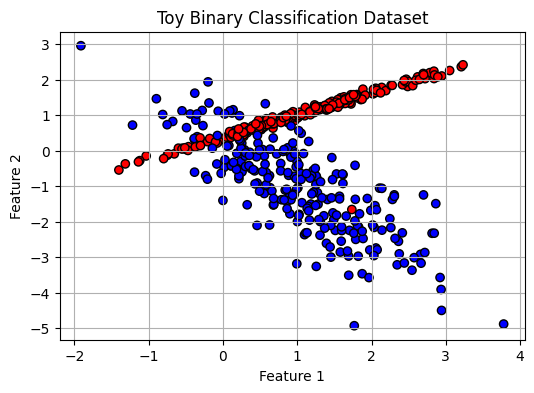

In [ ]:
# AdaBoost from scratch (for understanding) and using sklearn

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay

# Generate a toy dataset
X, y = make_classification(n_samples=500, n_features=2, n_informative=2,
                           n_redundant=0, n_clusters_per_class=1, random_state=42)

print("Features")
print(X[:5])
print("Target")
print(y[:5])
# Visualize dataset
plt.figure(figsize=(6, 4))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k')
plt.title("Toy Binary Classification Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

Gradient Boosting Test Accuracy: 0.9400


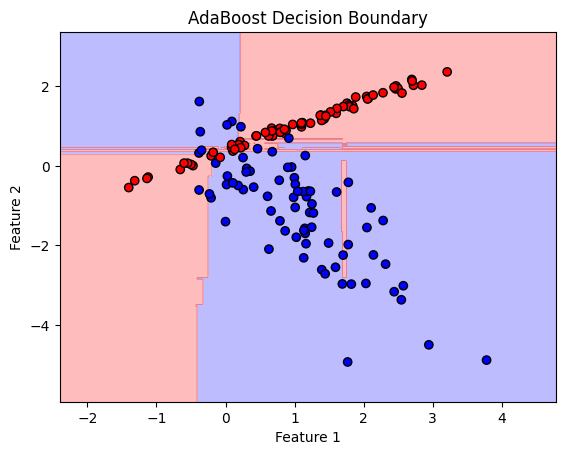

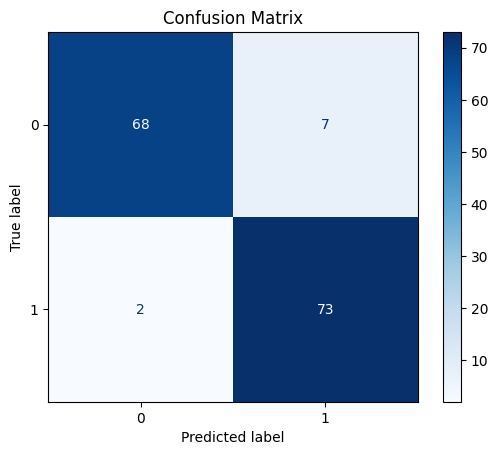

In [ ]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

gradient_boosting_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3, # Max depth of each tree
    subsample=0.8, # Fraction of samples for fitting
    random_state=42
)

# Fit the model to the training data (conceptual)
gradient_boosting_model.fit(X_train, y_train)

# Make predictions on the test set (conceptual)
y_pred_gbm = gradient_boosting_model.predict(X_test)

# Evaluate accuracy (conceptual)
print(f"Gradient Boosting Test Accuracy: {accuracy_score(y_test, y_pred_gbm):.4f}")


# Plot decision boundary
def plot_decision_boundary(clf, X, y):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 500),
                         np.linspace(y_min, y_max, 500))
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='bwr')
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap='bwr', edgecolor='k')
    plt.title("AdaBoost Decision Boundary")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.show()

plot_decision_boundary(gradient_boosting_model, X_test, y_test)

# Optional: Visualize confusion matrix
ConfusionMatrixDisplay.from_estimator(gradient_boosting_model, X_test, y_test, cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


# Gradient Boosting vs. AdaBoost

While both are boosting algorithms that build models sequentially, their core difference lies in *how they correct mistakes*:

| Feature               | AdaBoost                                    | Gradient Boosting                                    |
| :-------------------- | :------------------------------------------ | :--------------------------------------------------- |
| **Focus of next Learner** | Misclassified samples (classification) or high-error samples (regression) | Residuals (errors) or pseudo-residuals (gradients of loss) |
| **Sample Weighting** | Adaptively reweights samples, giving more importance to misclassified/high-error ones. | Does NOT directly reweight samples. Instead, trains on the *residuals*. |
| **Learner Contribution** | Each learner has a vote weight ($\alpha_m$) based on its accuracy. | Each learner's prediction is scaled by a `learning_rate` and added to the ensemble. |
| **Common Weak Learner** | Often very shallow trees (decision stumps, `max_depth=1`). | Usually shallow to moderately deep regression trees (`max_depth=3-6`). |
| **Primary Mechanism** | Focuses on reducing bias by converting weak learners into strong ones by addressing hard examples. | Focuses on reducing errors (both bias and variance) by iteratively correcting the mistakes of the previous *ensemble*. |

---


# Resources

* [Adaboost Algorithm](https://www.analyticsvidhya.com/blog/2021/09/adaboost-algorithm-a-complete-guide-for-beginners/)

* [Gradient Boosting Agorithm](https://www.analyticsvidhya.com/blog/2021/09/gradient-boosting-algorithm-a-complete-guide-for-beginners/)

* [Gradient Boosting](https://www.geeksforgeeks.org/machine-learning/ml-gradient-boosting/)

* [AdaBoost - Complete guide for beginners](https://www.analyticsvidhya.com/blog/2021/09/adaboost-algorithm-a-complete-guide-for-beginners/)